# Capstone 2: Territory Analysis with Python 
## EmporiUm Sales Territory Comparison: Texas vs. Florida

**Analyst:** Angel S. Osorio

**Territory 1 — Texas:** Manager: Jeff "Howdy" Richards | Stores 901–911 | Region Director: Andy Gisselquist  
**Territory 2 — Florida:** Manager: Lana Ilana | Stores 719–729 | Region Director: Andy Gisselquist  
**Region:** South

In this notebook, I'll performs a full territory analysis comparing the two South Region sales territories managed
by Jeff "Howdy" Richards (Texas) and Lana Ilana (Florida).
I'll explore monthly revenue trends, store
performance rankings, top customers, and product-category insights.
Lastly, I'll close with a targeted marketing recommendation for the next quarter.


## Importing the Libraries & Loading the Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Libraries loaded successfully")


Libraries loaded successfully


In [2]:
sales = pd.read_csv('StoreSales.csv')
stores = pd.read_csv('StoreDetail.csv')
products = pd.read_csv('Products_New.csv')
categories = pd.read_csv('ProductCategories.csv')
customers = pd.read_csv('customer_list.csv', sep='|')

sales.info()
stores.info()
products.info()
categories.info()
customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int

## Core Marketing Analysis

### Q1: Territory Overview: Managers, Store IDs & Cities

> *Who are the territory managers for the assigned sales territories?
> What are the store IDs and cities for the stores in each territory?*


In [3]:
jeff_stores = stores[stores['Territory Manager'] == 'Jeff "Howdy" Richards']
lana_stores = stores[stores['Territory Manager'] == 'Lana Ilana']

print("TEXAS STORES")
print(jeff_stores[['Store ID','Store Location']])

print("\nFLORIDA STORES")
print(lana_stores[['Store ID','Store Location']])


TEXAS STORES
     Store ID Store Location
100       901      Arlington
101       902         Austin
102       903        Bacliff
103       904        Baytown
104       905       Beaumont
105       906     Cedar Park
106       907         Dallas
107       908         Denton
108       909         Desoto
109       910     Fort Worth
110       911     Georgetown

FLORIDA STORES
    Store ID   Store Location
26       719   Cape Canaveral
27       720  Fort Lauderdale
28       721     Jacksonville
29       722         Key West
30       723         Lakeland
31       724            Miami
32       725           Naples
33       726          Orlando
34       727          Sebring
35       728      Tallahassee
36       729            Tampa


### Q2: Monthly Total Revenue by Territory

> *What is monthly total revenue for in-store sales in each of the two
> sales territories, over the full period covered by the data?*


In [4]:
sales['Transaction Date'] = pd.to_datetime(sales['Transaction Date'])
sales['YearMonth'] = sales['Transaction Date'].dt.to_period('M')

jeff_ids = jeff_stores['Store ID'].tolist()
lana_ids = lana_stores['Store ID'].tolist()

jeff_sales = sales[sales['Store ID'].isin(jeff_ids)]
lana_sales = sales[sales['Store ID'].isin(lana_ids)]

jeff_monthly = jeff_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()
lana_monthly = lana_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()

monthly = jeff_monthly.merge(lana_monthly,on='YearMonth',suffixes=('_TX','_FL'))
monthly['Month'] = monthly['YearMonth'].astype(str)

monthly.head()


,YearMonth,Sale Amount_TX,Sale Amount_FL,Month
0,2022-01,40857.20,48143.95,2022-01
1,2022-02,52729.22,46257.35,2022-02
2,2022-03,49214.95,53541.25,2022-03
3,2022-04,55229.25,49505.25,2022-04
4,2022-05,49696.98,58326.64,2022-05


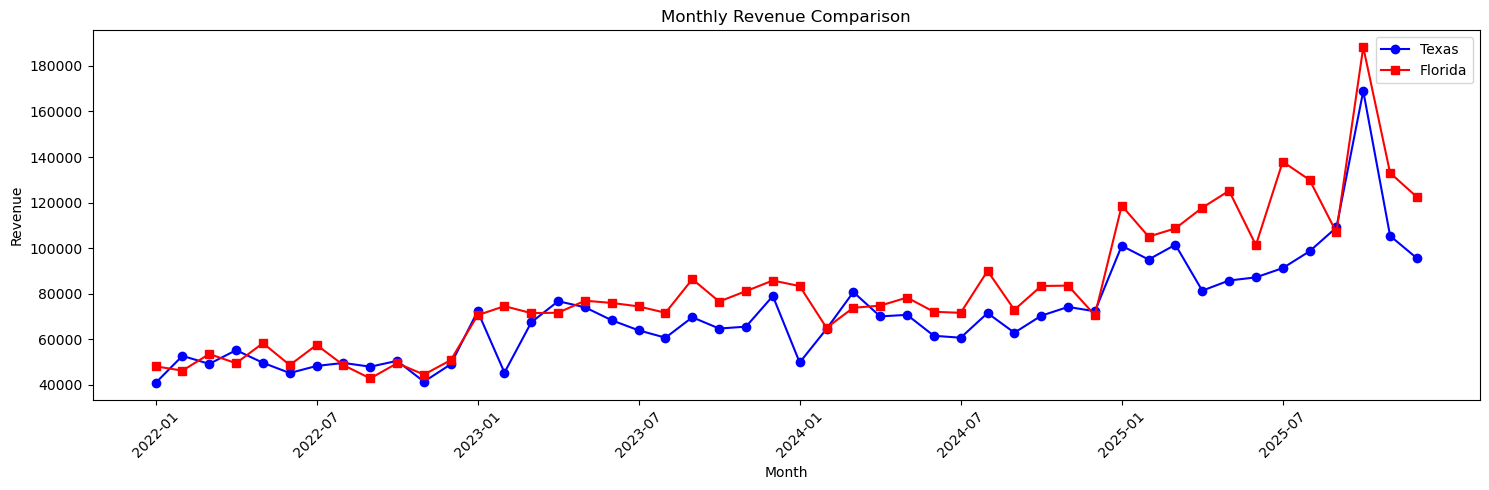

In [15]:
plt.figure(figsize=(15,5))

plt.plot(monthly['Month'],
         monthly['Sale Amount_TX'],
         marker='o',
         label='Texas',
         color='blue')

plt.plot(monthly['Month'],
         monthly['Sale Amount_FL'],
         marker='s',
         label='Florida',
         color='red')

plt.title('Monthly Revenue Comparison')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(range(0, len(monthly), 6), monthly['Month'].iloc[::6], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Q3: Store Performance Ranking

> *How would you rank the sales performance of each store in each territory?
> Which are the top performing stores?*


In [6]:
texas_rankings = jeff_sales.groupby('Store ID').agg(
    Total_Revenue=('Sale Amount','sum'),
    Transactions=('Sale Amount','count'),
    Avg_Transaction=('Sale Amount','mean')
).reset_index()

texas_rankings = texas_rankings.merge(
    jeff_stores[['Store ID','Store Location']],
    on='Store ID'
)

texas_rankings = texas_rankings.sort_values(
    'Total_Revenue',
    ascending=False
)

texas_rankings


,Store ID,Total_Revenue,Transactions,Avg_Transaction,Store Location
4,905,637818.90,4403,144.860073,Beaumont
9,910,351772.59,2208,159.317296,Fort Worth
8,909,330720.12,2343,141.152420,Desoto
5,906,312628.27,2320,134.753565,Cedar Park
3,904,298163.16,2218,134.428837,Baytown
7,908,298111.45,2164,137.759450,Denton
0,901,292987.49,2257,129.812800,Arlington
1,902,291145.00,2226,130.792902,Austin
2,903,280714.34,2174,129.123431,Bacliff
10,911,269344.64,1469,183.352376,Georgetown


In [7]:
florida_rankings = lana_sales.groupby('Store ID').agg(
    Total_Revenue=('Sale Amount','sum'),
    Transactions=('Sale Amount','count'),
    Avg_Transaction=('Sale Amount','mean')
).reset_index()

florida_rankings = florida_rankings.merge(
    lana_stores[['Store ID','Store Location']],
    on='Store ID'
)

florida_rankings = florida_rankings.sort_values(
    'Total_Revenue',
    ascending=False
)

florida_rankings


,Store ID,Total_Revenue,Transactions,Avg_Transaction,Store Location
5,724,618846.25,4457,138.848160,Miami
9,728,541670.66,4320,125.386727,Tallahassee
3,722,332620.43,2228,149.291037,Key West
0,719,331956.13,2241,148.128572,Cape Canaveral
2,721,331667.08,2280,145.468018,Jacksonville
8,727,330848.14,2235,148.030488,Sebring
10,729,308979.01,2226,138.804587,Tampa
1,720,302270.07,2277,132.749262,Fort Lauderdale
7,726,297891.71,2271,131.172043,Orlando
4,723,273835.24,2144,127.721660,Lakeland


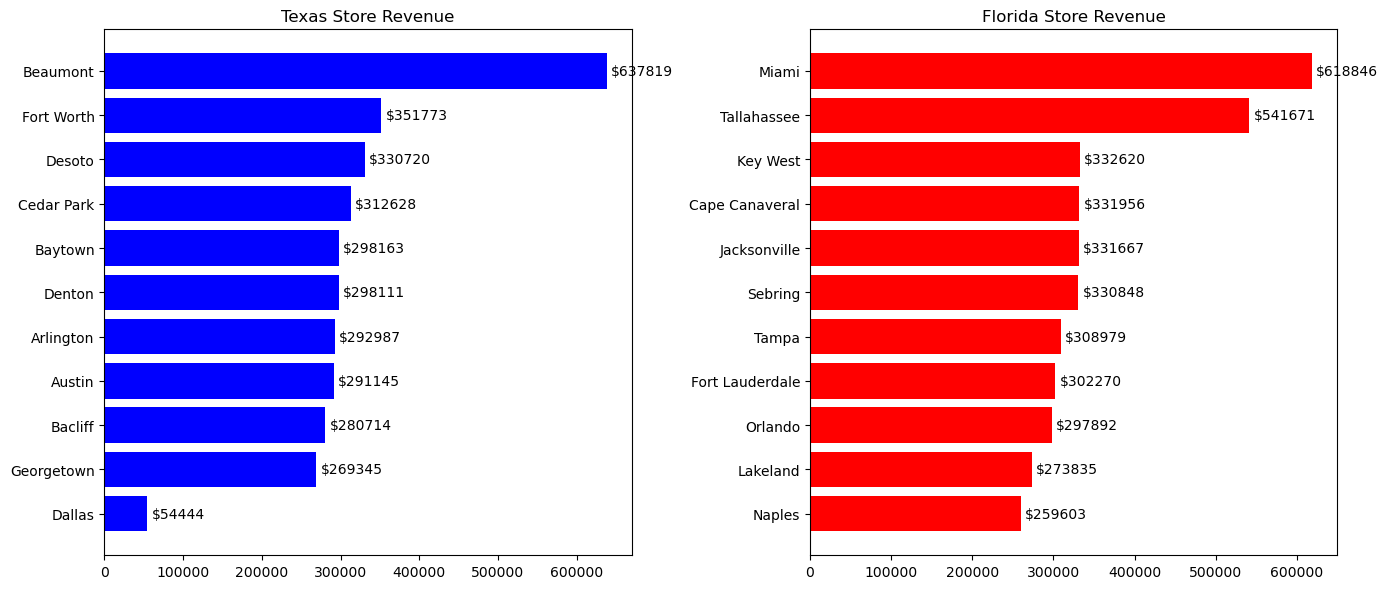

In [31]:
jeff_chart = texas_rankings.sort_values('Total_Revenue')
lana_chart = florida_rankings.sort_values('Total_Revenue')

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,6))

bars1 = ax1.barh(jeff_chart['Store Location'],
                 jeff_chart['Total_Revenue'],
                 color='blue')
ax1.set_title('Texas Store Revenue')
ax1.bar_label(bars1, fmt='$%.0f', padding=3)

bars2 = ax2.barh(lana_chart['Store Location'],
                 lana_chart['Total_Revenue'],
                 color='red')
ax2.set_title('Florida Store Revenue')
ax2.bar_label(bars2, fmt='$%.0f', padding=3)

plt.tight_layout()
plt.show()


### Q4: Top Customers by Territory

> *Comparing the customer ID from the customer list with the rewards ID from
> the sales data, who were the top customers in each territory?*


In [9]:
rewards_sales = jeff_sales[jeff_sales['RewardsID'].notna()].copy()
rewards_sales['RewardsID'] = rewards_sales['RewardsID'].astype(int)

top_customers = rewards_sales.groupby('RewardsID').agg(
    Total_Spend=('Sale Amount','sum'),
    Transactions=('Sale Amount','count')
).reset_index()

top_customers = top_customers.merge(
    customers[['cust_id','name','email']],
    left_on='RewardsID',
    right_on='cust_id',
    how='left'
)

top_customers = top_customers.sort_values(
    'Total_Spend',
    ascending=False
)

top_customers.head(10)


,RewardsID,Total_Spend,Transactions,cust_id,name,email
341,344,5240.86,10,344,Nate Jacobs,nate@easthighland.high
470,474,3479.46,7,474,Christopher Moltisanti,chrism@northjersey.net
100,102,3464.91,13,102,Jodie L.,jodie@lawndale.high
166,168,3400.35,9,168,Darius,darius@paperboi.atl
268,271,3127.53,11,271,Maeby F.,maeby@bluthcompany.biz
482,486,2845.84,6,486,Pete Campbell,pete@sterlingcooper.com
198,200,2843.74,12,200,Animal,animal@muppetstudios.com
387,390,2757.26,4,390,Dot Com,dotcom@tgs.nbc
259,262,2715.74,4,262,Hollyhock,hollyhock@hollywoo.net
151,153,2708.13,4,153,Chachi A.,chachi@arnoldsdrivein.diner


In [14]:
rewards_sales = lana_sales[lana_sales['RewardsID'].notna()].copy()
rewards_sales['RewardsID'] = rewards_sales['RewardsID'].astype(int)

top_customers = rewards_sales.groupby('RewardsID').agg(
    Total_Spend=('Sale Amount','sum'),
    Transactions=('Sale Amount','count')
).reset_index()

top_customers = top_customers.merge(
    customers[['cust_id','name','email']],
    left_on='RewardsID',
    right_on='cust_id',
    how='left'
)

top_customers = top_customers.sort_values(
    'Total_Spend',
    ascending=False
)

top_customers.head(10)

,RewardsID,Total_Spend,Transactions,cust_id,name,email
45,47,4954.99,10,47,Stanley H.,stanley@dundermifflin.com
257,259,4549.16,10,259,Todd Chavez,todd@hollywoo.net
188,190,4415.78,13,190,Huck,huck@oliviapopeandassociates.com
333,335,3631.94,7,335,John Locke,locke@dharma.initiative
162,164,3535.88,10,164,Dr. Ray Flemming,flemming@lapd.gov
416,418,3387.58,6,418,Ernie,ernie@sesamestreet.org
54,56,3355.68,8,56,Leslie Knope,leslie@pawnee.gov
141,143,3325.45,6,143,Billy Abbott,billy@genoa.city
210,212,3225.15,6,212,Geoffrey,geoffrey@banksresidence.la
213,215,3204.56,13,215,Lisa W.,lisa@banksresidence.la


### Q5: Transactions & Revenue by Product Category

> *What is the number of transactions per month by product category in each territory?
> What is total sales revenue per month by category?
> What might this tell you about the most popular products, and where could there be opportunity for growth?*


In [10]:
jeff_full = jeff_sales.merge(
    products[['Prod Num','CategoryID']],
    on='Prod Num',
    how='left'
)

jeff_full = jeff_full.merge(
    categories[['CategoryID','Category']].drop_duplicates(),
    on='CategoryID',
    how='left'
)

lana_full = lana_sales.merge(
    products[['Prod Num','CategoryID']],
    on='Prod Num',
    how='left'
)

lana_full = lana_full.merge(
    categories[['CategoryID','Category']].drop_duplicates(),
    on='CategoryID',
    how='left'
)


In [11]:
jeff_cat = jeff_full.groupby('Category').agg(
    Total_Revenue=('Sale Amount','sum'),
    Transactions=('Sale Amount','count')
).reset_index()

lana_cat = lana_full.groupby('Category').agg(
    Total_Revenue=('Sale Amount','sum'),
    Transactions=('Sale Amount','count')
).reset_index()

cat_compare = jeff_cat.merge(
    lana_cat,
    on='Category',
    suffixes=('_TX','_FL')
)

cat_compare


,Category,Total_Revenue_TX,Transactions_TX,Total_Revenue_FL,Transactions_FL
0,Apparel and Merchandise,142403.22,4406,180626.02,5539
1,Art Supplies,120953.81,3787,147371.61,4596
2,Books (General),58436.68,1981,70124.49,2366
3,Stationery and Supplies,54322.23,5396,61114.75,6128
4,Technology & Accessories,2445117.66,5219,2764161.11,5934
5,Textbooks,596616.41,3423,706789.57,4053


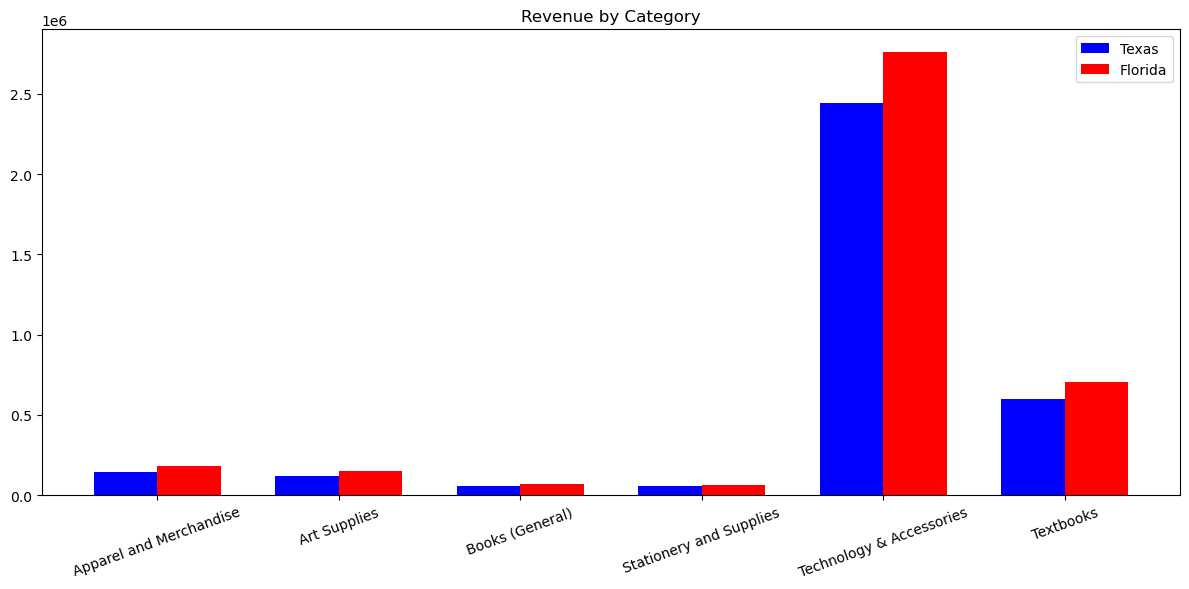

In [12]:
x = np.arange(len(cat_compare))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x-width/2,
        cat_compare['Total_Revenue_TX'],
        width,
        label='Texas', color='blue')

plt.bar(x+width/2,
        cat_compare['Total_Revenue_FL'],
        width,
        label='Florida', color='red')

plt.xticks(x,cat_compare['Category'],rotation=20)
plt.title('Revenue by Category')
plt.legend()
plt.tight_layout()
plt.show()


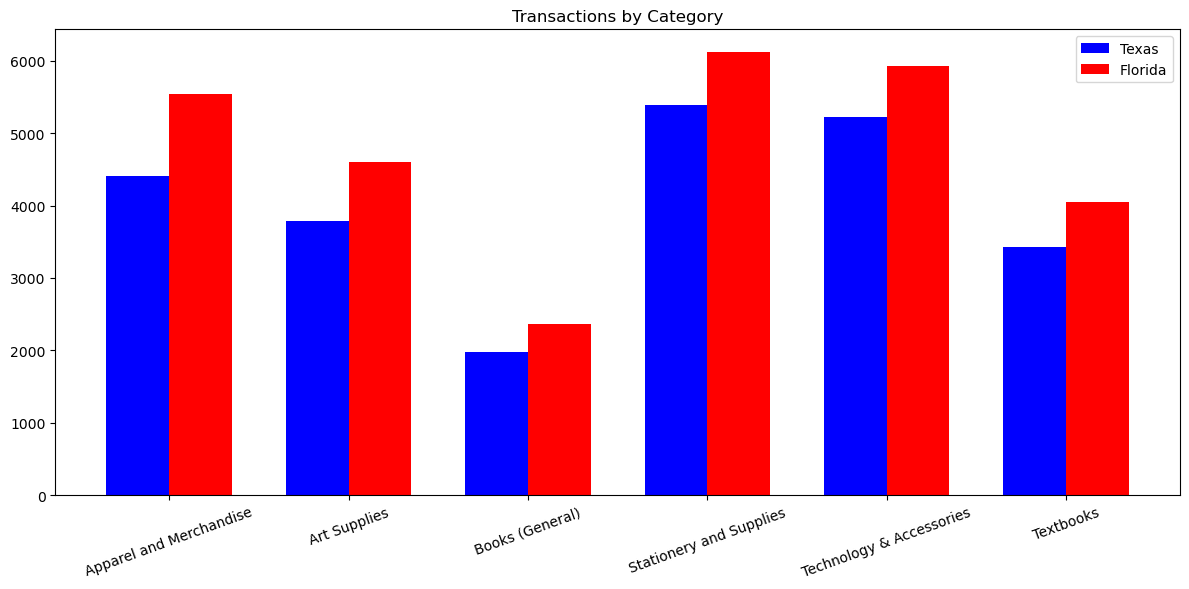

In [13]:
x = np.arange(len(cat_compare))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x-width/2,
        cat_compare['Transactions_TX'],
        width,
        label='Texas', color='blue')

plt.bar(x+width/2,
        cat_compare['Transactions_FL'],
        width,
        label='Florida', color='red')

plt.xticks(x,cat_compare['Category'],rotation=20)
plt.title('Transactions by Category')
plt.legend()
plt.tight_layout()
plt.show()


### Q6: Marketing Recommendation for Next Quarter

> *What is your recommendation for where to focus marketing attention in the next quarter?*

---

#### Summary of Key Findings

| Metric | Texas (Jeff Richards) | Florida (Lana Ilana) |
|---|---|---|
| Total Revenue | ~$3.42M | ~$3.93M |
| Total Transactions | 24,212 | 28,616 |
| # of Stores | 11 | 11 |
| Avg Revenue/Store | ~$310K | ~$357K |
| Top Store | Beaumont ($638K) | *(see chart)* |
| Lowest Store | Dallas ($54K) | *(see chart)* |
| Top Category | Technology & Accessories | Technology & Accessories |

---

#### Findings & Insights

**1. Florida outperforms Texas across the board.** Florida generates ~$510K more in revenue from the same number of stores. Average revenue per store is ~15% higher, suggesting Jeff's territory has room to grow, either from market conditions, marketing gaps, or operational differences worth investigating.

**2. Dallas is a huge outlier in Texas.** With only $54K in total revenue and 430 transactions, Dallas drastically underperforms compared to every other Texas store. Given that Dallas is one of the largest areas in the country, this represents the single biggest growth opportunity in Jeff's territory. A targeted investigation into Dallas (visibility, marketing spend, competition, location) is recommended.

**3. Technology & Accessories drives the business.** Across both territories, Tech & Accessories represents roughly 70% of total revenue. However, Stationery & Supplies has more transactions per dollar than any other category, lots of small purchases. There is an upsell opportunity here to bundle stationery with tech accessories at checkout.

**4. Textbooks are the #2 revenue driver.** Textbook revenue tracks closely with the academic calendar, suggesting a strong seasonal pattern. Both territories should prioritize pre-semester inventory and promotions in late July/August and late December/January.

**5. Rewards membership is low.** Only a fraction of total transactions have a RewardsID attached. Growing the loyalty program, especially in Texas, could improve customer retention data, and enable future targeted campaigns.

---

#### Recommendation

**Priority 1: Investigate and revitalize the Dallas store.** This is the simplest revenue opportunity in Jeff's territory. Bringing Dallas up to the average of the other Texas stores would add ~$250K in annual revenue.

**Priority 2: Rewards member acquisition push.** Launch an in-store sign-up campaign across both territories, especially timed to semester starts. Rewards members spend more per visit (see top customer data) and can be targeted with promotions.

**Priority 3: Pre-semester Tech + Textbook bundle promotions.** August and January are natural high traffic windows. A bundled promotion combining top selling tech accessories with required textbooks could drive basket size and introduce customers to higher cost product lines.

**Priority 4: Stationery upsell program.** Stationery has the highest transaction count but lowest revenue per transaction. Point-of-sale upsell prompts or "add-on" bundles (a notebook/pen set with any laptop purchase) could meaningfully lift category revenue without additional foot traffic.
